In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

projection_method = "MDS"

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf"])
df = qm9.load()
X=np.array(df["acsf_embedding"].to_list())

2026-05-08 09:53:16.987 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-08 09:53:17.330 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-05-08 09:53:17.331 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-05-08 09:53:17.337 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-08 09:53:20.260 | SUCCESS  | src.datasets:add_acsf:1262 - Added ACSF embeddings and matrices.
2026-05-08 09:53:20.260 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['acsf_embedding', 'acsf_matrix']
2026-05-08 09:53:20.262 | INFO     | src.datasets:load:907 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=5000, returned_rows=5000, base_rows=5500.


In [4]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="acsf",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=4,
)

2026-05-08 09:53:20.330 | INFO     | src.datasets:get_distance_matrix:1479 - Applying PCA to reduce 'acsf' to 4 dimensions.
2026-05-08 09:53:20.331 | INFO     | src.datasets:get_distance_matrix:1483 - PCA kept 96.37% of the variance for 'acsf'.
2026-05-08 09:53:20.332 | INFO     | src.datasets:get_distance_matrix:1485 - PCA reduced 'acsf' dimensions from 65 to 4
2026-05-08 09:53:20.345 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for acsf using euclidean distance.
2026-05-08 09:53:20.477 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_acsf_euclidean_pca4.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:15<00:00,  1.53s/it]


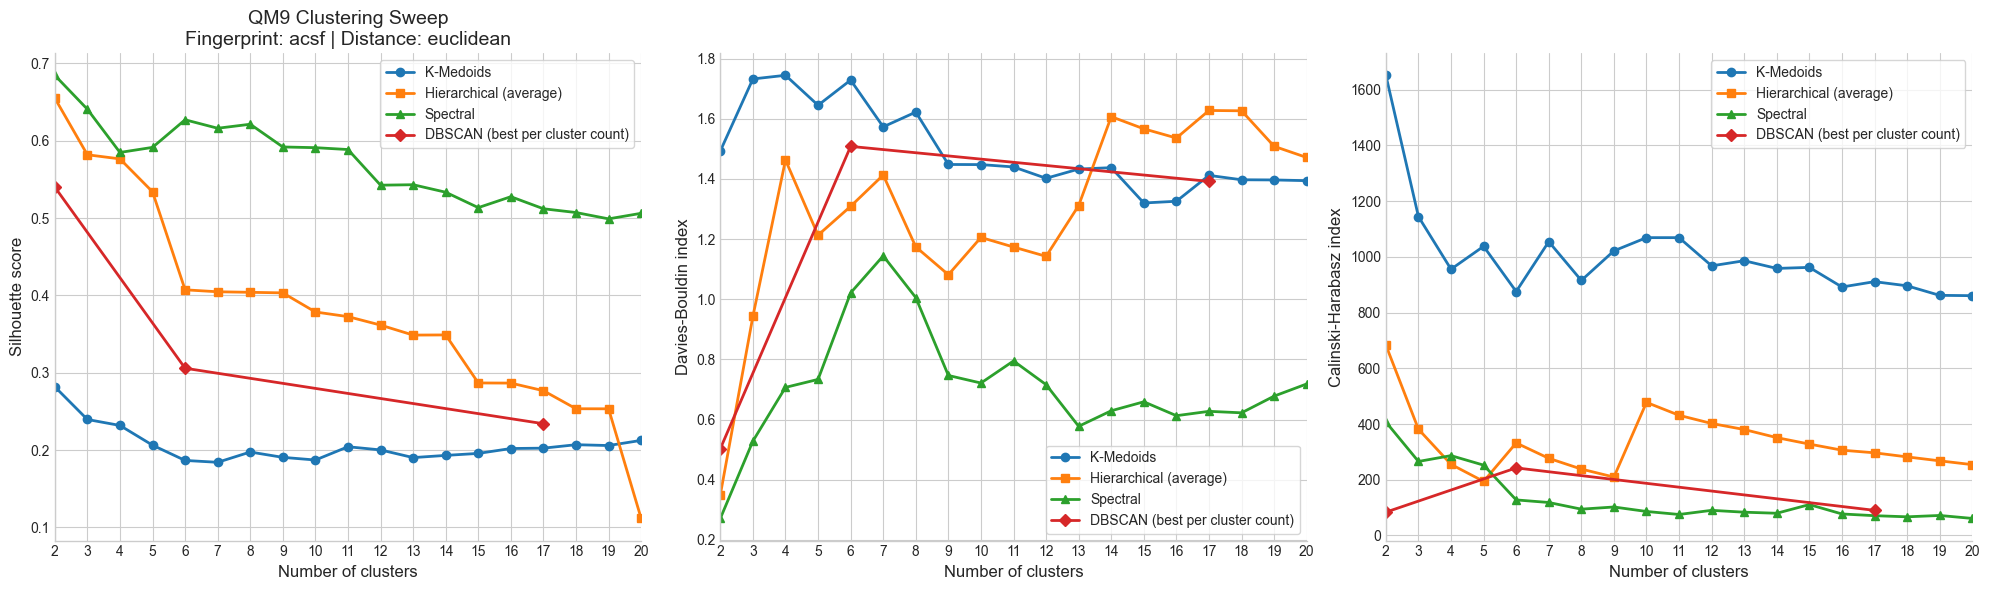

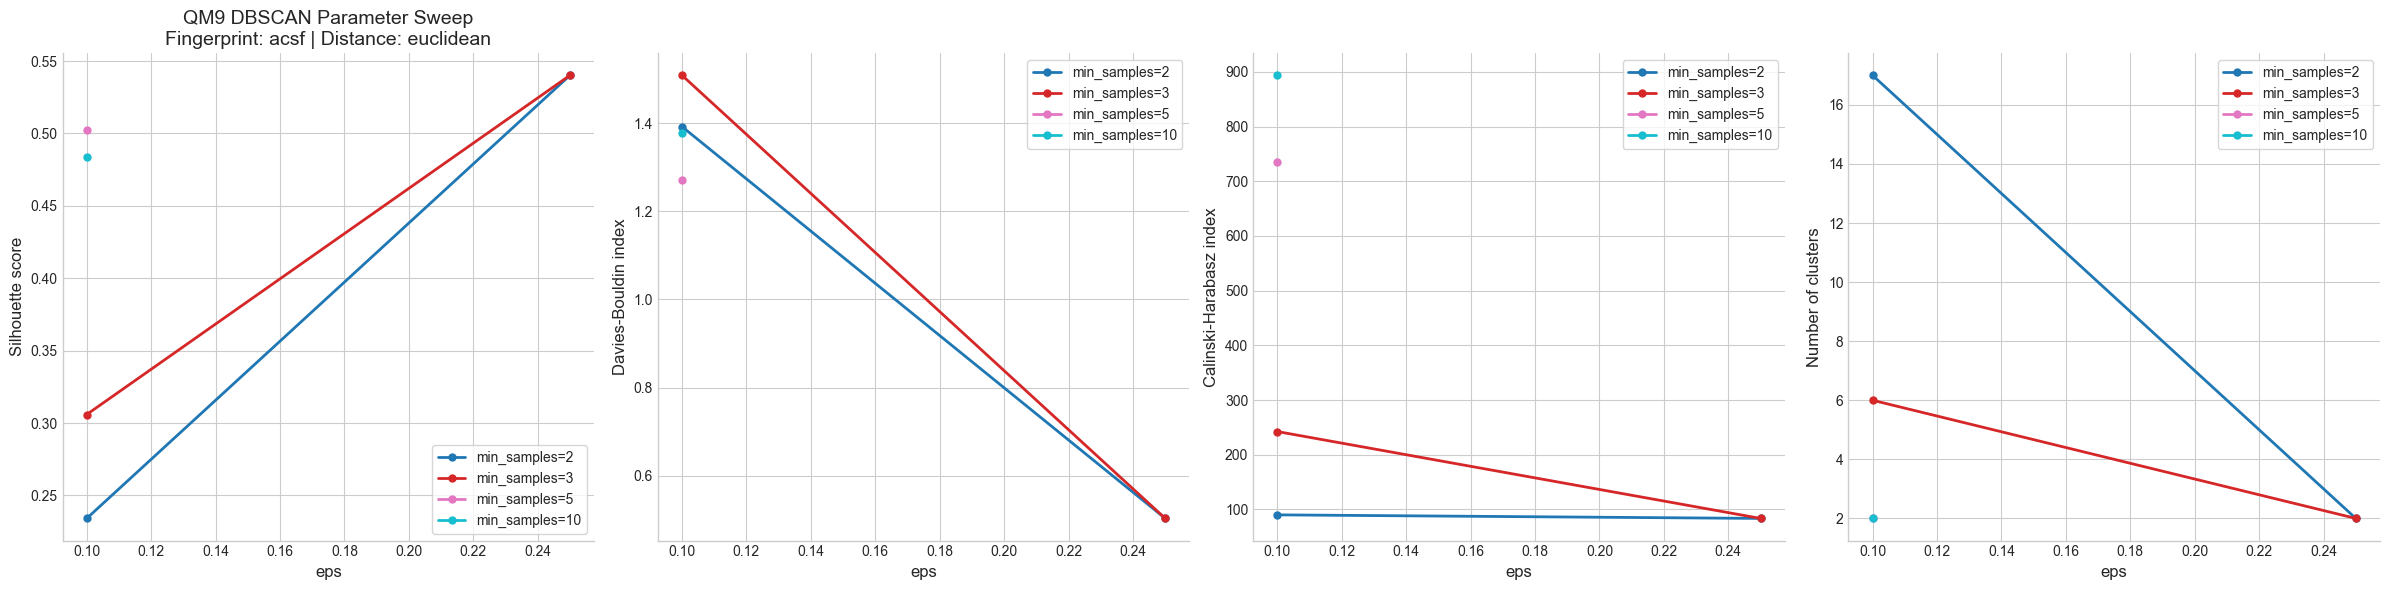

2026-05-07 18:06:53.442 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1060 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.png
2026-05-07 18:06:53.443 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/acsf/dbscan_parameter_sweep.png
2026-05-07 18:06:53.443 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1063 - Saved clustering sweep results to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.json


In [5]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

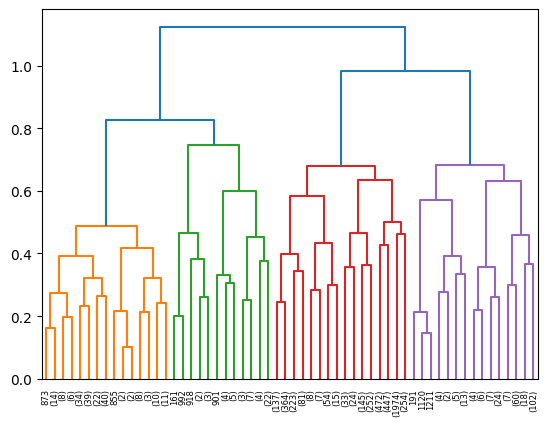

In [5]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [6]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [7]:
create_chemiscope_viewer(df, X, labels_hier, 'PCA')

2026-05-08 09:53:23.181 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-08 09:53:23.182 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-08 09:54:11.294 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-08 09:54:11.302 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-08 09:54:11.548 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-08 09:54:11.620 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

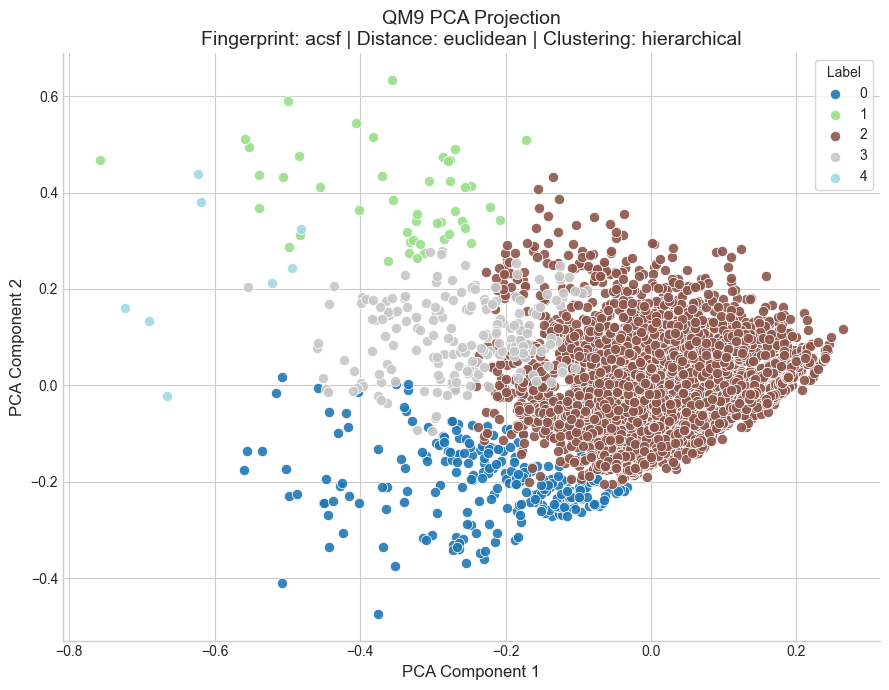

2026-05-07 21:24:04.831 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png


In [7]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [10]:
average_numeric_by_cluster(df, "labels_hier")

shape: (5, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4832,0.751705,0.0,122.806498,0.065604,35.355132,0.879301,12.834548,8.781871,1.705505,0.096854,0.000414,2.316432,18.686465,2.065124,2.349959,0.064125,0.187705,0.74817,0.94702,1.923427,6.620861,0.423427,1.117964,4.924048,6.354925,13.838783,1.262344,0.001656,0.390522,0.020281,0.126656,0.138038,0.001449,0.0387,0.130381,0.54346,0.0,2.646942,75.673409,-6.530602,0.429782,6.960393,1194.310816,4.172742,-11111.694054,-11111.460479,-11111.434784,-11112.606168,32.048032,-77.396973,-77.872421,-78.319551,-72.01824,3.341463,1.39274,1.123684,80.153146,9.519868,10.326987,13.838783,1429,"""Acyclic""",10.326987,335,"""C1CC1""",10.471854,1,null,0.0
1,22,1.000535,0.0,108.136364,-0.318182,75.136364,0.15472,13.363796,7.772727,1.0,0.954545,0.090909,4.863636,11.090909,2.0,1.090909,0.086364,0.875758,0.037879,1.090909,4.045455,3.772727,0.318182,2.5,0.090909,5.590909,11.045455,1.267167,0.0,0.0,0.136364,0.5,0.0,0.0,0.0,0.0,0.045455,0.0,3.346441,57.362273,-7.021651,-1.591495,5.429661,800.178187,2.028318,-10803.071333,-10802.89988,-10802.874379,-10803.903387,22.726636,-48.18406,-48.434811,-48.690599,-44.95439,5.747693,2.149075,1.517921,4.545455,90.909091,4.545455,11.045455,19,"""c1cnncn1""",9.090909,7,"""C1CCCCC1""",45.454545,1,null,0.0
2,137,0.990248,0.0,118.481752,-0.065693,42.890511,0.953649,12.636663,8.686131,1.627737,0.430657,0.029197,2.781022,13.357664,2.070444,0.80292,0.210375,0.487722,0.301903,0.532847,2.50365,4.846715,1.350365,2.708029,1.846715,6.087591,13.153285,1.280276,0.0,0.153285,0.109489,0.109489,0.094891,0.0,0.131387,0.255474,0.49635,0.0,3.132405,69.457153,-6.674496,-1.22769,5.446746,1069.497645,2.52511,-11448.912936,-11448.711422,-11448.685754,-11449.790738,27.235504,-61.725115,-62.031725,-62.344781,-57.828903,4.174731,1.489849,1.145376,50.364964,40.145985,9.489051,13.153285,81,"""Acyclic""",9.489051,39,"""C1CCCC1""",19.708029,1,null,0.0
3,4,1.189394,0.0,115.0,-0.25,68.25,0.665573,13.269953,8.0,1.0,0.75,0.25,5.25,9.75,2.0,0.5,0.0,0.916667,0.083333,0.0,4.25,3.25,0.0,2.5,0.25,4.75,11.5,1.300552,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.5,0.25,3.743975,49.2775,-8.238927,-2.595966,5.642961,782.064255,1.486578,-12533.803467,-12533.63916,-12533.61377,-12534.644531,20.87575,-43.777037,-43.979726,-44.198112,-40.95516,4.45313,1.984052,1.357993,25.0,75.0,0.0,11.5,4,"""O=C1N=COCO1""",25.0,3,"""CC1CCCCC1""",50.0,1,null,0.0
4,5,1.213629,0.0,122.4,0.4,18.4,1.751222,13.889181,7.8,0.2,0.0,3.0,4.2,10.8,1.842828,0.8,0.2,0.183333,0.616667,0.2,1.2,2.8,0.8,0.6,2.2,4.8,13.0,1.306619,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.2,0.4,0.0,2.77938,43.564,-7.852662,-0.45443,7.398232,928.317908,1.788577,-14386.706055,-14386.501367,-14386.476172,-14387.603516,25.455,-46.771534,-46.983179,-47.234998,-43.677414,4.125354,1.46514,1.327496,20.0,0.0,80.0,13.0,2,"""Acyclic""",80.0,2,"""Acyclic""",80.0,1,null,0.0


# KMedoids

In [13]:
model_km = KMedoids(n_clusters=6, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2, 3, 4, 5], dtype=uint64), array([ 772,  379,  967,  971,  843, 1068]))


In [14]:
create_chemiscope_viewer(df, X, labels_km, 'PCA')

2026-05-08 10:02:40.865 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-08 10:02:40.866 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-08 10:03:28.973 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-08 10:03:28.982 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-08 10:03:29.226 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-08 10:03:29.296 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

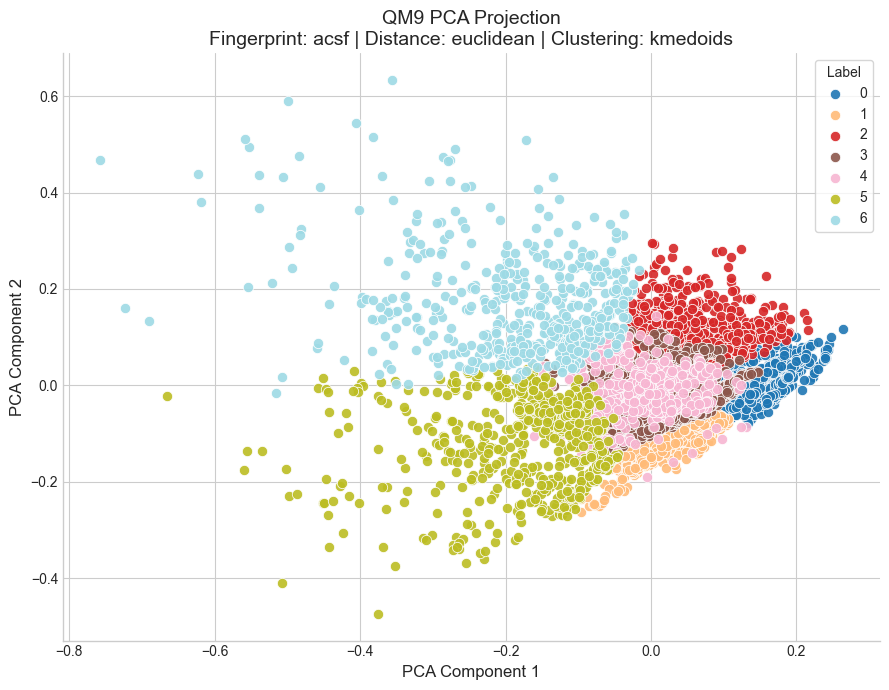

2026-05-08 10:01:48.877 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png


{'coords': array([[ 0.20875781,  0.05614784],
        [ 0.00449045,  0.12605686],
        [ 0.14453078, -0.05179985],
        ...,
        [ 0.11019953, -0.01004256],
        [ 0.04467002, -0.01505755],
        [ 0.11716493,  0.09256946]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'kmedoids'}

In [11]:
plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [14]:
average_numeric_by_cluster(df, "labels_km")

shape: (2, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1773,0.870754,0.0,121.338973,-0.15454,41.57304,0.863316,12.790402,8.781726,1.940214,0.223914,0.013536,2.715172,16.078962,2.095993,1.367174,0.107961,0.324152,0.567887,0.921038,2.257191,6.032149,0.689791,1.820643,3.55612,6.060914,13.892273,1.273794,0.004512,0.264523,0.053582,0.170333,0.139876,0.0,0.06881,0.191201,0.549351,0.000564,2.967515,71.751596,-6.527813,-0.338175,6.189636,1080.754955,3.341759,-11342.623459,-11342.411819,-11342.386125,-11343.510313,29.125851,-69.265177,-69.660346,-70.039266,-64.625279,3.519525,1.524859,1.198637,0.184433,72.194021,21.658206,6.147772,13.892273,810,"""Acyclic""",6.147772,248,"""C1CCCC1""",12.972363,1,null,0.0
1,3227,0.699378,0.0,123.318872,0.178494,32.544469,0.887386,12.856183,8.768516,1.565231,0.047722,0.0,2.140998,19.817787,2.047521,2.81097,0.046532,0.131062,0.822406,0.942361,1.780911,6.839479,0.315773,0.80973,5.502014,6.495507,13.75705,1.256964,0.0,0.446235,0.006508,0.104121,0.13418,0.002169,0.02572,0.101333,0.534552,0.0,2.497754,77.356945,-6.545757,0.762451,7.308216,1247.792462,4.537714,-11003.864785,-11003.621073,-11003.595382,-11004.788665,33.361632,-80.911178,-81.421286,-81.898311,-75.210809,3.298004,1.330274,1.086717,0.00031,82.584444,4.772234,12.643322,13.75705,895,"""Acyclic""",12.643322,220,"""C1CC1""",12.767276,1,null,0.0


# Spectral

In [15]:
gaussian_kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(gaussian_kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4983,   11,    6]))


In [16]:
create_chemiscope_viewer(df, X, labels_spectral, 'PCA')

2026-05-08 10:05:15.835 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-08 10:05:15.836 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-08 10:06:04.128 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-08 10:06:04.136 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-08 10:06:04.377 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-08 10:06:04.446 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


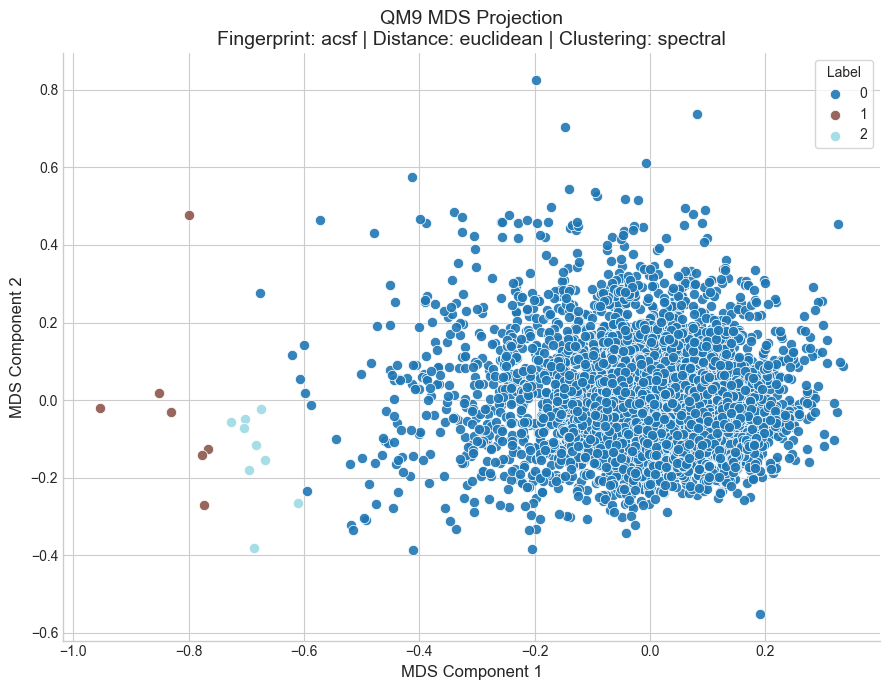

2026-05-07 18:28:36.190 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/euclidean/acsf/mds_spectral_projection.png


In [ ]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [18]:
_=average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

# DBSCAN 

In [19]:
model_db = DBSCAN(
    eps=0.6,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([0]), array([5000]))


In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 18:28:37.658 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 18:28:37.659 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 18:29:35.418 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 18:29:35.443 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 18:29:35.739 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 18:29:35.824 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


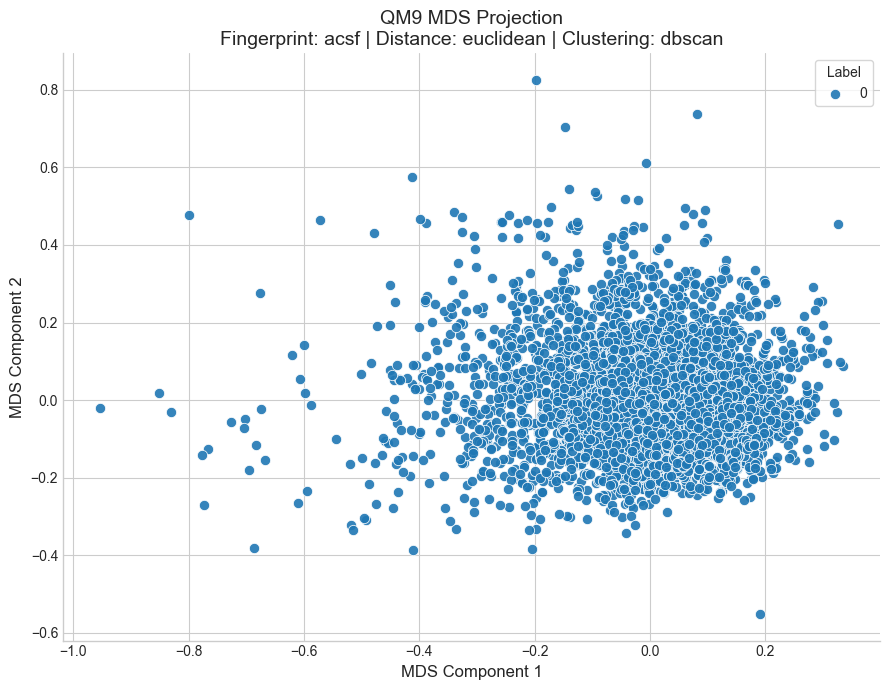

2026-05-07 19:06:16.177 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/euclidean/acsf/mds_dbscan_projection.png


{'coords': array([[ 0.21299491, -0.18740343],
        [-0.07319544, -0.17634305],
        [ 0.28017857, -0.0086134 ],
        ...,
        [ 0.13635626, -0.06895122],
        [ 0.06684668, -0.00136854],
        [ 0.18287386, -0.17540026]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/mds_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'dbscan'}

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [22]:
average_numeric_by_cluster(df, "labels_db")

shape: (1, 74)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,5000,0.760148,0.0,122.6168,0.0604,35.746,0.878851,12.832857,8.7732,1.6982,0.1102,0.0048,2.3446,18.492,2.064709,2.299,0.068315,0.199532,0.732154,0.9348,1.9498,6.5532,0.4484,1.1682,4.812,6.3414,13.805,1.262932,0.0016,0.3818,0.0232,0.1276,0.1362,0.0014,0.041,0.1332,0.5398,0.0002,2.664332,75.369288,-6.539394,0.372169,6.911567,1188.560962,4.113629,-11123.988611,-11123.756272,-11123.730579,-11124.899361,31.859624,-76.781506,-77.250857,-77.693094,-71.45718,3.376555,1.399274,1.126404,0.0656,0.6454,0.005,78.9,10.76,10.34,13.805,1478,"""Acyclic""",10.34,342,"""C1CCCC1""",10.8,1,null,0.0


In [23]:
from src.helper_functions import evaluate_hdbscan_grid
import hdbscan
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=20, ms=1, clusters=49, noise=0.32, persistence=0.088, score=0.059
mcs=40, ms=1, clusters=27, noise=0.43, persistence=0.096, score=0.054
mcs=60, ms=1, clusters=20, noise=0.49, persistence=0.106, score=0.054
mcs=10, ms=1, clusters=74, noise=0.30, persistence=0.074, score=0.052
mcs=10, ms=1, clusters=74, noise=0.30, persistence=0.074, score=0.052
mcs=10, ms=2, clusters=65, noise=0.36, persistence=0.077, score=0.049
mcs=20, ms=2, clusters=47, noise=0.38, persistence=0.077, score=0.048
mcs=60, ms=10, clusters=2, noise=0.32, persistence=0.067, score=0.046
mcs=40, ms=20, clusters=2, noise=0.42, persistence=0.075, score=0.043
mcs=300, ms=1, clusters=2, noise=0.50, persistence=0.084, score=0.042
mcs=80, ms=10, clusters=2, noise=0.32, persistence=0.059, score=0.040
mcs=220, ms=1, clusters=2, noise=0.50, persistence=0.079, score=0.040


In [24]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 19:06:51.566 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 19:06:51.566 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 19:07:40.809 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 19:07:40.817 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 19:07:41.278 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 19:07:41.345 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


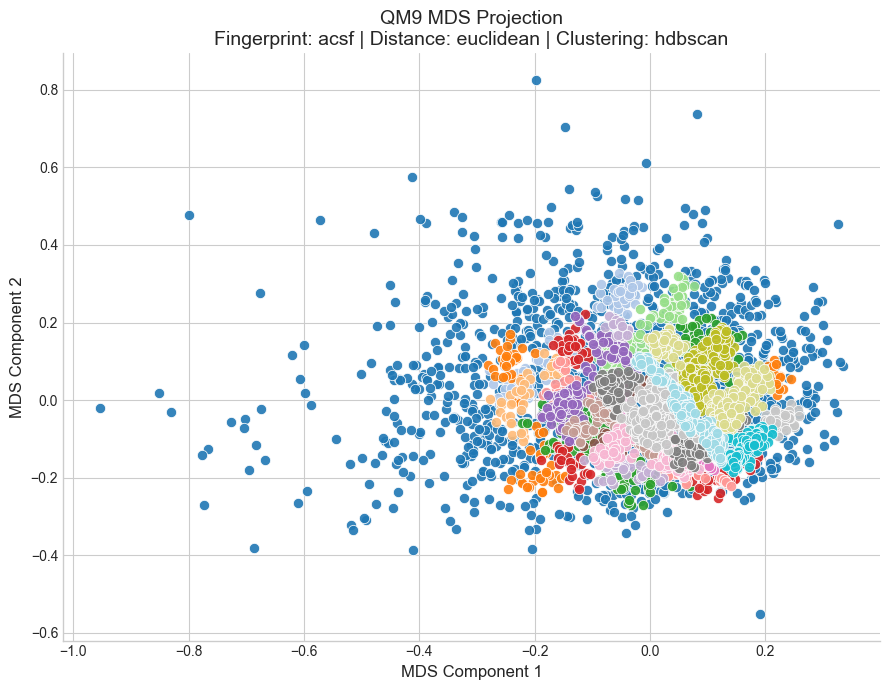

2026-05-07 19:11:38.889 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/euclidean/acsf/mds_hdbscan_projection.png


{'coords': array([[ 0.21299491, -0.18740343],
        [-0.07319544, -0.17634305],
        [ 0.28017857, -0.0086134 ],
        ...,
        [ 0.13635626, -0.06895122],
        [ 0.06684668, -0.00136854],
        [ 0.18287386, -0.17540026]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/mds_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'hdbscan'}

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [27]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (50, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1621,0.766963,0.0,119.481801,0.022209,41.634176,0.843669,12.857188,8.552128,1.160395,0.228871,0.014806,2.668106,16.980259,2.014958,2.449722,0.124029,0.283723,0.592248,0.906231,2.231956,5.693399,0.797039,1.506477,3.580506,6.53979,12.708822,1.256967,0.003701,0.306601,0.048118,0.19926,0.142505,0.003701,0.051203,0.133868,0.548427,0.000617,2.904489,72.605065,-6.605338,-0.009956,6.595402,1223.097945,3.662893,-11064.219575,-11063.985952,-11063.960274,-11065.140033,30.984408,-71.325131,-71.735605,-72.139423,-66.462999,4.00125,1.378613,1.092102,0.186305,0.531154,0.015423,0.0,54.349167,22.208513,23.44232,12.708822,441,"""Acyclic""",23.44232,120,"""Acyclic""",23.44232,1,null,0.0
0,31,0.954762,0.0,126.516129,-0.290323,63.064516,0.916055,12.844579,8.967742,1.322581,0.322581,0.0,3.967742,14.129032,2.039708,1.580645,0.096774,0.458065,0.445161,0.935484,3.548387,4.967742,0.483871,2.290323,2.225806,5.967742,13.483871,1.27862,0.0,0.387097,0.16129,0.129032,0.290323,0.0,0.225806,0.096774,0.935484,0.0,3.34019,64.778387,-6.984285,-1.001993,5.981589,1118.178585,2.705555,-12790.757655,-12790.541362,-12790.515562,-12791.659463,28.552645,-62.964586,-63.284218,-63.615798,-58.839892,3.284434,1.380592,1.054586,0.0,0.0,0.0,0.0,61.290323,32.258065,6.451613,13.483871,27,"""c1cocn1""",6.451613,19,"""C1CCCC1""",19.354839,1,null,0.0
1,30,0.795349,0.0,124.666667,-0.533333,64.633333,0.556054,13.081076,8.9,1.266667,0.5,0.0,4.0,16.766667,2.030766,2.0,0.02,0.581667,0.398333,2.1,2.766667,6.833333,0.1,2.833333,1.966667,6.4,13.266667,1.252631,0.0,0.1,0.1,0.633333,0.333333,0.0,0.0,0.033333,0.066667,0.0,3.294113,74.500666,-6.032492,-0.681373,5.351482,1145.452238,3.348273,-11705.446354,-11705.22679,-11705.20127,-11706.341243,29.8369,-68.029084,-68.414795,-68.792582,-63.378998,3.26363,1.461818,1.013195,0.0,0.0,0.0,0.0,46.666667,50.0,3.333333,13.266667,25,"""c1cc[nH]c1""",10.0,12,"""C1CCCC1""",40.0,1,null,0.0
2,45,0.875372,0.0,125.666667,-0.577778,62.0,0.711606,12.971125,8.955556,1.377778,0.2,0.0,3.977778,15.422222,2.040329,1.355556,0.076667,0.46,0.463333,1.377778,2.866667,6.0,0.377778,2.288889,2.311111,5.977778,13.444444,1.269793,0.0,0.111111,0.044444,0.4,0.733333,0.0,0.133333,0.044444,0.422222,0.0,3.724769,69.062222,-6.669208,-0.773106,5.896042,1101.048444,3.048704,-12233.588542,-12233.372461,-12233.346636,-12234.488064,29.018867,-65.792598,-66.149461,-66.505817,-61.38514,3.043867,1.45335,1.087888,0.0,0.0,0.0,0.0,68.888889,20.0,11.111111,13.444444,38,"""Acyclic""",11.111111,24,"""C1CCCC1""",17.777778,1,null,0.0
3,37,1.001782,0.0,121.864865,0.027027,38.513514,1.006997,12.590751,8.945946,2.135135,0.054054,0.0,2.459459,14.540541,2.140283,0.702703,0.189189,0.271042,0.539768,0.27027,2.378378,5.27027,1.243243,1.72973,3.513514,5.837838,14.567568,1.291146,0.027027,0.243243,0.0,0.027027,0.027027,0.0,0.243

# KMeans

In [28]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
X = np.array(df['acsf_embedding'].to_list())
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))


(array([0, 1, 2], dtype=int32), array([1587,  726, 2687]))


In [29]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-07 19:11:39.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 19:11:39.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 19:12:27.211 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 19:12:27.225 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 19:12:27.495 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 19:12:27.568 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [30]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1587,0.85758,0.0,121.830498,-0.046629,35.426591,0.954437,12.731548,8.803403,2.10586,0.101449,0.011972,2.371141,16.63201,2.110146,1.42155,0.104168,0.232624,0.663208,0.722117,2.098299,6.081285,0.698173,1.436673,4.297417,6.068683,14.164461,1.27655,0.004411,0.3661,0.026465,0.064272,0.088847,0.0,0.079395,0.226213,…,2.736701,72.331934,-6.607766,-0.130654,6.477088,1093.457548,3.536585,-11327.659583,-11327.445133,-11327.419452,-11328.549463,29.675365,-71.613828,-72.031504,-72.427313,-66.789272,3.44605,1.504782,1.215524,0.167612,0.175173,0.0,0.0,16.491493,83.868935,10.018904,6.112161,14.164461,714,"""Acyclic""",6.112161,258,"""C1CCCC1""",8.065532,1,null,0.0
1,726,0.825458,0.0,121.104683,-0.402204,55.995868,0.622429,12.999138,8.706612,1.381543,0.451791,0.006887,3.527548,16.190083,2.038581,1.742424,0.082422,0.459216,0.458363,1.545455,2.615702,6.219008,0.451791,2.263085,2.464187,6.260331,13.179063,1.258625,0.001377,0.104683,0.090909,0.450413,0.297521,0.004132,0.015152,0.057851,…,3.363918,71.772534,-6.277078,-0.300255,5.976868,1106.71578,3.341083,-11315.394375,-11315.177154,-11315.151442,-11316.288859,29.363231,-67.63512,-68.02014,-68.396049,-63.03265,3.693963,1.496619,1.117986,0.085399,0.360882,0.034435,0.0,4.946281,47.245179,43.663912,9.090909,13.179063,334,"""Acyclic""",9.090909,94,"""C1CCCC1""",26.997245,1,null,0.0
2,2687,0.684956,0.0,123.489766,0.248604,30.463342,0.90349,12.847765,8.773353,1.542985,0.023074,0.0,2.009304,20.212505,2.044932,2.967622,0.043328,0.109822,0.84685,0.895422,1.682173,6.922218,0.299963,0.713807,5.750279,6.524377,13.761816,1.256052,0.0,0.465947,0.002977,0.077782,0.120581,0.001489,0.025307,0.098623,…,2.432568,78.13502,-6.569887,0.850829,7.420726,1266.844817,4.663177,-10951.980268,-10951.733278,-10951.707584,-10952.90774,33.824194,-82.304908,-82.827564,-83.315143,-76.490369,3.249749,1.310657,1.076042,0.0,1.0,0.0,0.0,27.386677,84.51805,2.307406,13.174544,13.761816,722,"""Acyclic""",13.174544,190,"""C1CC1""",13.844436,1,null,0.0
